In [7]:
import sys
sys.path.append('/home/jack/Dev/candles-bot/scripts')

import importlib
import smc_features
importlib.reload(smc_features)

from smc_features import (
    set_dark_theme,
    add_rsi_ribbon,
    add_smc_features,
    add_confirmation_features,
    add_kill_zones_forex,
    compute_zones,
    plot_smc_chart,
    build_pipeline,
    align_timeframes
)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

set_dark_theme()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device         : {device}")
print(f"build_pipeline : {build_pipeline}")
print("Imports OK !")

Device         : cuda
build_pipeline : <function build_pipeline at 0x735e28f79090>
Imports OK !


In [8]:
SYMBOL = "EURUSD=X"
print(f"Téléchargement {SYMBOL}...")

df_1d_raw = yf.download(SYMBOL, start="2020-01-01",
                        interval='1d', progress=False)
df_1d_raw.columns = [col[0] for col in df_1d_raw.columns]

df_4h_raw = yf.download(SYMBOL, period="729d",
                        interval='4h', progress=False)
df_4h_raw.columns = [col[0] for col in df_4h_raw.columns]

df_1h_raw = yf.download(SYMBOL, period="729d",
                        interval='1h', progress=False)
df_1h_raw.columns = [col[0] for col in df_1h_raw.columns]

print(f"Daily brut : {len(df_1d_raw)} bougies")
print(f"4H brut    : {len(df_4h_raw)} bougies")
print(f"1H brut    : {len(df_1h_raw)} bougies")

# Pipelines
df_1d = build_pipeline(df_1d_raw, '1D')
df_4h = build_pipeline(df_4h_raw, '4H')
df_1h = build_pipeline(df_1h_raw, '1H')

print(f"\nShapes finales :")
print(f"  Daily : {df_1d.shape}")
print(f"  4H    : {df_4h.shape}")
print(f"  1H    : {df_1h.shape}")

Téléchargement EURUSD=X...
Daily brut : 1645 bougies
4H brut    : 4359 bougies
1H brut    : 17247 bougies

Pipeline 1D...
  Kill Zones   : (1645, 13)
  RSI Ribbon   : (1645, 18)
  SMC Features : (1626, 32)
  ATR + CVD    : (1577, 45)
  Shape final  : (1577, 45)
  Période      : 2020-04-06 → 2026-04-28

Pipeline 4H...
  Kill Zones   : (4359, 13)
  RSI Ribbon   : (4359, 18)
  SMC Features : (4340, 32)
  ATR + CVD    : (4163, 45)
  Shape final  : (4163, 45)
  Période      : 2023-07-28 → 2026-04-28

Pipeline 1H...
  Kill Zones   : (17247, 13)
  RSI Ribbon   : (17247, 18)
  SMC Features : (17228, 32)
  ATR + CVD    : (11089, 45)
  Shape final  : (11089, 45)
  Période      : 2023-07-19 → 2026-04-24

Shapes finales :
  Daily : (1577, 45)
  4H    : (4163, 45)
  1H    : (11089, 45)


In [9]:
df_mtf = align_timeframes(df_1d, df_4h, df_1h)

cols_1h = [c for c in df_mtf.columns if c.endswith('_1H')]
cols_4h = [c for c in df_mtf.columns if c.endswith('_4H')]
cols_1d = [c for c in df_mtf.columns if c.endswith('_1D')]

print(f"\nFeatures par groupe :")
print(f"  OHLCV   : 5")
print(f"  1H      : {len(cols_1h)}")
print(f"  4H      : {len(cols_4h)}")
print(f"  Daily   : {len(cols_1d)}")
print(f"  Total   : {df_mtf.shape[1]}")

Alignement des timeframes...
Shape fusionné : (10965, 125)
Période        : 2023-07-28 → 2026-04-24

Features par groupe :
  OHLCV   : 5
  1H      : 40
  4H      : 40
  Daily   : 40
  Total   : 125


In [10]:
def prepare_ml_data(df_mtf, horizon=1, pip_threshold=10):
    df  = df_mtf.copy()
    pip = 0.0001

    # Label — hausse > pip_threshold pips dans horizon bougies
    future     = df['Close'].shift(-horizon)
    df['Label']= (
        (future - df['Close']) > pip_threshold * pip
    ).astype(int)

    # Features sélectionnées
    all_features = []
    for col in df.columns:
        if col in ['Label', 'Close', 'Open',
                   'High', 'Low', 'Volume']:
            continue
        # Garder uniquement les features numériques
        if df[col].dtype in ['float64', 'int64', 'int32']:
            all_features.append(col)

    df = df[all_features + ['Label', 'Close']].dropna()

    print(f"Features totales  : {len(all_features)}")
    print(f"Bougies totales   : {len(df)}")
    hausse = df['Label'].sum()
    total  = len(df)
    print(f"Label hausse      : {hausse} ({hausse/total*100:.1f}%)")
    print(f"Label baisse      : {total-hausse} "
          f"({(total-hausse)/total*100:.1f}%)")
    print(f"Seuil             : {pip_threshold} pips")

    return df, all_features

df_ml, features = prepare_ml_data(
    df_mtf,
    horizon       = 1,
    pip_threshold = 10
)

# Sauvegarder
df_ml.to_csv(
    '/home/jack/Dev/candles-bot/data/eurusd_mtf_features.csv')
print("\nDataset sauvegardé !")

Features totales  : 114
Bougies totales   : 10965
Label hausse      : 1129 (10.3%)
Label baisse      : 9836 (89.7%)
Seuil             : 10 pips

Dataset sauvegardé !


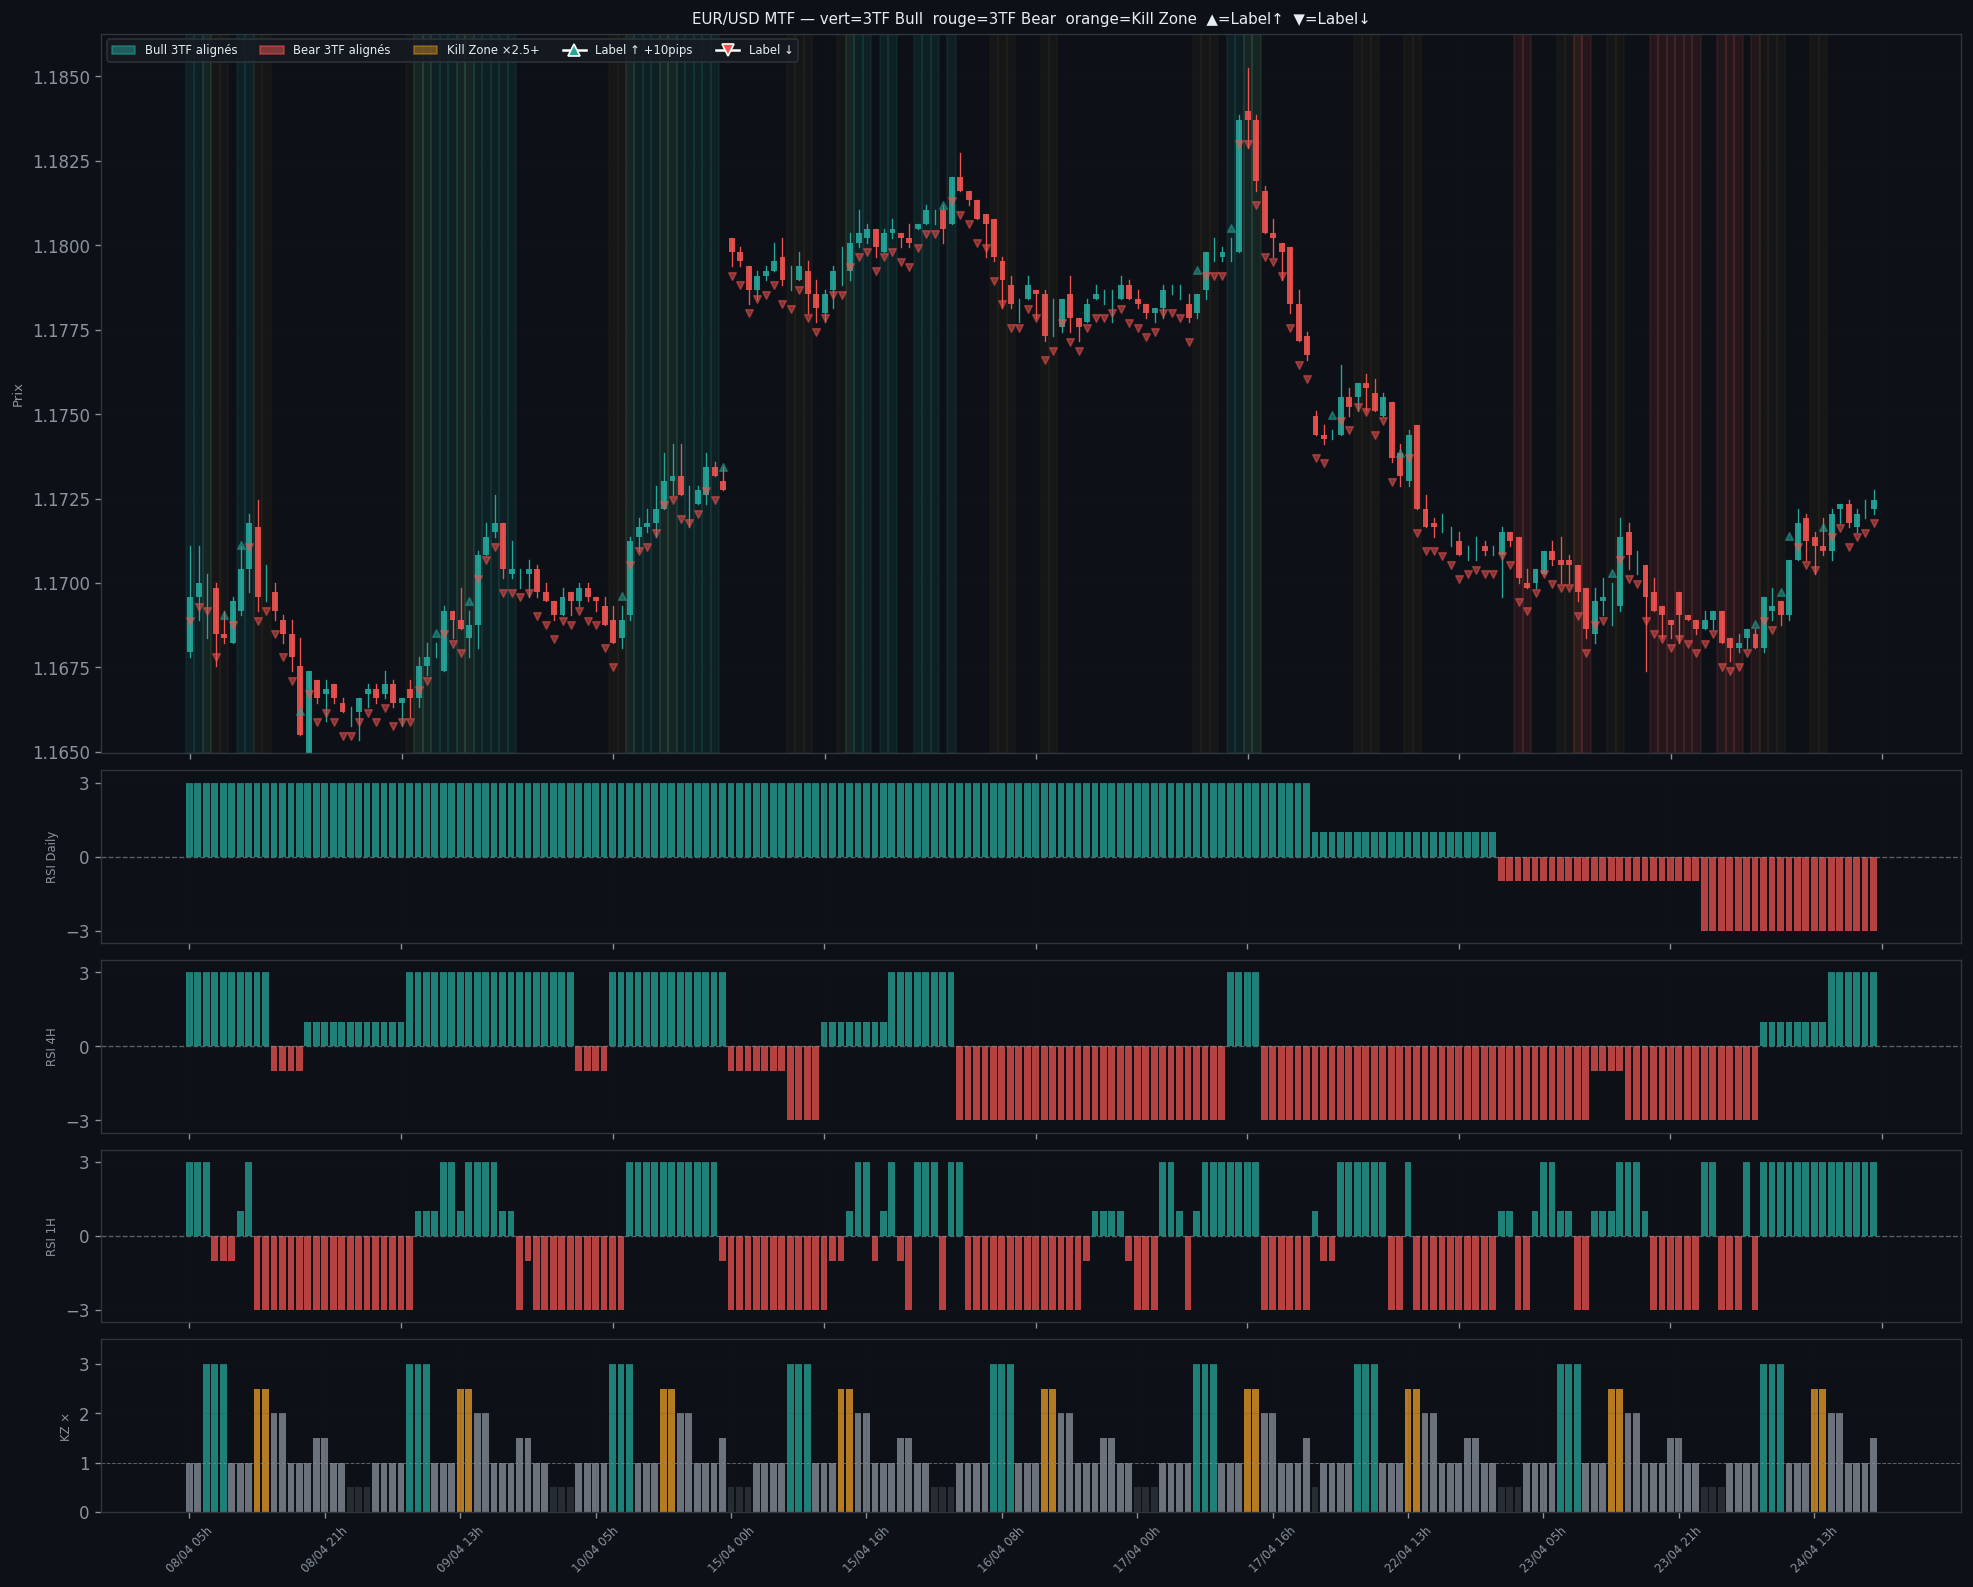

Sauvegardé : eurusd_mtf_confluence.png


In [15]:
%matplotlib inline

def plot_mtf_confluence(df_ml, df_1h_ohlc, n_bars=150):

    # Préparer OHLC depuis données brutes
    df_ohlc = df_1h_ohlc[['Open','High','Low','Close']].copy()
    df_ohlc.index = pd.to_datetime(df_ohlc.index, utc=True)

    # Fusionner features ML + OHLC
    df_full = df_ml.copy()
    df_full = df_full.join(df_ohlc, how='left', rsuffix='_ohlc')

    # Récupérer OHLC
    for col in ['Open','High','Low','Close']:
        ohlc_col = f"{col}_ohlc"
        if ohlc_col in df_full.columns:
            df_full[col] = df_full[ohlc_col]

    df = df_full.tail(n_bars).copy()
    n  = len(df)

    fig, axes = plt.subplots(
        5, 1, figsize=(20, 16),
        facecolor='#0d1117',
        gridspec_kw={
            'height_ratios': [5, 1.2, 1.2, 1.2, 1.2],
            'hspace'       : 0.06
        })

    for ax in axes:
        ax.set_facecolor('#0d1117')
        ax.tick_params(colors='#8b949e')
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')

    ax1, ax2, ax3, ax4, ax5 = axes

    # ── BOUGIES ────────────────────────────────────────────────
    for i in range(n):
        row = df.iloc[i]
        try:
            o = float(row['Open'])
            h = float(row['High'])
            l = float(row['Low'])
            c = float(row['Close'])
            if any(pd.isna([o, h, l, c])):
                continue
            color = '#26a69a' if c >= o else '#ef5350'
            ax1.bar(i, abs(c - o),
                    bottom=min(o, c),
                    color=color, width=0.7,
                    alpha=0.9, zorder=2)
            ax1.plot([i, i], [l, h],
                     color=color, linewidth=0.8, zorder=2)
        except Exception as e:
            continue

    closes = df['Close'].values.astype(float)

    # ── RSI SCORES ─────────────────────────────────────────────
    rsi_1d = df['RSI_score_1D'].values if 'RSI_score_1D' in df.columns else np.zeros(n)
    rsi_4h = df['RSI_score_4H'].values if 'RSI_score_4H' in df.columns else np.zeros(n)
    rsi_1h = df['RSI_score_1H'].values if 'RSI_score_1H' in df.columns else np.zeros(n)
    kz     = df['kz_multiplier_1H'].values if 'kz_multiplier_1H' in df.columns else np.ones(n)

    # ── CONFLUENCE SURBRILLANCE ────────────────────────────────
    for i in range(n):
        if rsi_1d[i] > 0 and rsi_4h[i] > 0 and rsi_1h[i] > 0:
            ax1.axvspan(i-0.5, i+0.5,
                       alpha=0.10, color='#26a69a', zorder=0)
        elif rsi_1d[i] < 0 and rsi_4h[i] < 0 and rsi_1h[i] < 0:
            ax1.axvspan(i-0.5, i+0.5,
                       alpha=0.10, color='#ef5350', zorder=0)
        if kz[i] >= 2.5:
            ax1.axvspan(i-0.5, i+0.5,
                       alpha=0.04, color='#EF9F27', zorder=0)

    # ── LABELS ─────────────────────────────────────────────────
    if 'Label' in df.columns:
        label_vals = df['Label'].values
        for i in range(n):
            l     = label_vals[i]
            price = closes[i]
            if pd.isna(price):
                continue
            color  = '#26a69a' if l == 1 else '#ef5350'
            marker = '^' if l == 1 else 'v'
            offset = 1.0006 if l == 1 else 0.9994
            ax1.scatter(i, price * offset,
                       marker=marker, s=20,
                       color=color, alpha=0.5, zorder=5)

    ax1.set_title(
        'EUR/USD MTF — vert=3TF Bull  rouge=3TF Bear  '
        'orange=Kill Zone  ▲=Label↑  ▼=Label↓',
        color='#e6edf3', fontsize=9)
    ax1.set_ylabel('Prix', fontsize=8, color='#8b949e')
    ax1.grid(True, alpha=0.15, color='#21262d')
    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, p: f'{v:.4f}'))

    # ── RSI PANELS ─────────────────────────────────────────────
    for ax, scores, label in [
        (ax2, rsi_1d, 'RSI Daily'),
        (ax3, rsi_4h, 'RSI 4H'),
        (ax4, rsi_1h, 'RSI 1H'),
    ]:
        bar_colors = [
            '#26a69a' if s > 0 else
            '#ef5350' if s < 0 else
            '#8b949e' for s in scores
        ]
        ax.bar(range(n), scores,
               color=bar_colors, alpha=0.75, width=0.8)
        ax.axhline(0, color='#8b949e',
                  linewidth=0.8, linestyle='--', alpha=0.6)
        ax.set_ylim(-3.5, 3.5)
        ax.set_yticks([-3, 0, 3])
        ax.set_ylabel(label, fontsize=7, color='#8b949e')
        ax.grid(True, alpha=0.15, color='#21262d')

    # ── KILL ZONE ──────────────────────────────────────────────
    kz_colors = []
    for v in kz:
        if   v >= 3.0: kz_colors.append('#26a69a')
        elif v >= 2.5: kz_colors.append('#EF9F27')
        elif v >= 1.0: kz_colors.append('#8b949e')
        else:          kz_colors.append('#30363d')
    ax5.bar(range(n), kz, color=kz_colors,
            alpha=0.75, width=0.8)
    ax5.axhline(1.0, color='#8b949e',
               linewidth=0.6, linestyle='--', alpha=0.6)
    ax5.set_ylim(0, 3.5)
    ax5.set_ylabel('KZ ×', fontsize=7, color='#8b949e')
    ax5.grid(True, alpha=0.15, color='#21262d')

    # ── LÉGENDE ────────────────────────────────────────────────
    leg = [
        mpatches.Patch(color='#26a69a', alpha=0.5,
                       label='Bull 3TF alignés'),
        mpatches.Patch(color='#ef5350', alpha=0.5,
                       label='Bear 3TF alignés'),
        mpatches.Patch(color='#EF9F27', alpha=0.4,
                       label='Kill Zone ×2.5+'),
        plt.Line2D([0],[0], marker='^', color='w',
                   markerfacecolor='#26a69a',
                   markersize=7, label='Label ↑ +10pips'),
        plt.Line2D([0],[0], marker='v', color='w',
                   markerfacecolor='#ef5350',
                   markersize=7, label='Label ↓'),
    ]
    ax1.legend(handles=leg, loc='upper left',
               fontsize=7, ncol=5,
               facecolor='#161b22', edgecolor='#30363d',
               framealpha=0.85)

    # ── DATES ──────────────────────────────────────────────────
    step     = max(1, n // 12)
    ticks    = list(range(0, n, step))
    labels_x = []
    for i in ticks:
        try:
            d = pd.Timestamp(df.index[i])
            labels_x.append(d.strftime('%d/%m %Hh'))
        except:
            labels_x.append(str(i))
    ax5.set_xticks(ticks)
    ax5.set_xticklabels(labels_x,
                        rotation=45, fontsize=7,
                        color='#8b949e')
    for ax in axes[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)

    # ── SAUVEGARDE ─────────────────────────────────────────────
    plt.savefig(
        '/home/jack/Dev/candles-bot/models/'
        'eurusd_mtf_confluence.png',
        bbox_inches='tight',
        facecolor='#0d1117', dpi=150)
    plt.show()
    print("Sauvegardé : eurusd_mtf_confluence.png")

# Lancer
plot_mtf_confluence(df_ml, df_1h_raw, n_bars=200)

=== df_ml ===
Shape  : (10965, 116)
Index  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Cols   : ['kz_asian_1H', 'kz_london_1H', 'kz_ny_1H', 'kz_london_cls_1H', 'kz_ny_cls_1H']
                           kz_asian_1H  kz_london_1H  kz_ny_1H  \
Datetime                                                         
2026-04-24 18:00:00+00:00            0             0         0   
2026-04-24 19:00:00+00:00            0             0         0   
2026-04-24 20:00:00+00:00            0             0         0   

                           kz_london_cls_1H  kz_ny_cls_1H  in_kill_zone_1H  \
Datetime                                                                     
2026-04-24 18:00:00+00:00                 0             0                0   
2026-04-24 19:00:00+00:00                 0             0                0   
2026-04-24 20:00:00+00:00                 0             1                0   

                           kz_multiplier_1H   RSI_7_1H  RSI_14_1H  RSI_21_1H  \
Datetime  

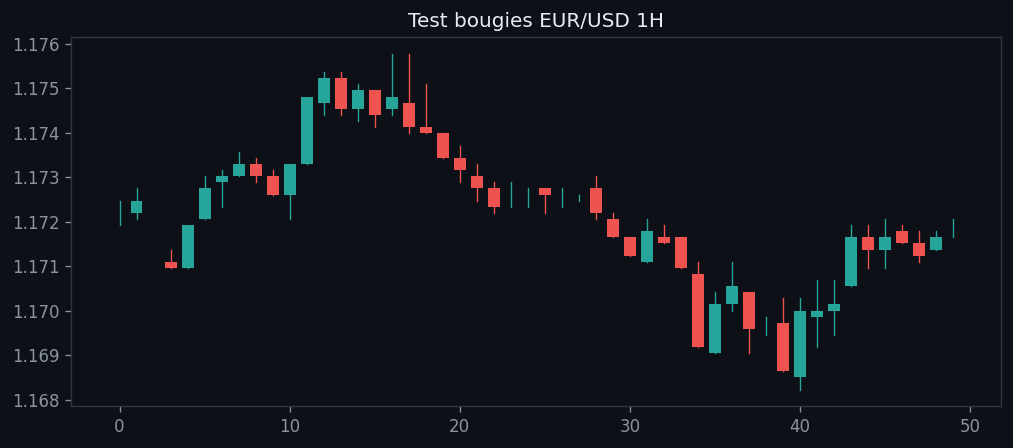

OK !


In [14]:
# Diagnostic complet
print("=== df_ml ===")
print(f"Shape  : {df_ml.shape}")
print(f"Index  : {type(df_ml.index)}")
print(f"Cols   : {df_ml.columns[:5].tolist()}")
print(df_ml.tail(3))

print("\n=== df_1h_raw ===")
print(f"Shape  : {df_1h_raw.shape}")
print(f"Cols   : {df_1h_raw.columns.tolist()}")
print(df_1h_raw.tail(3))

print("\n=== Test bougie simple ===")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))
df_test = df_1h_raw.tail(50)
for i, (date, row) in enumerate(df_test.iterrows()):
    c = '#26a69a' if row['Close'] >= row['Open'] else '#ef5350'
    ax.bar(i, abs(row['Close']-row['Open']),
           bottom=min(row['Open'], row['Close']),
           color=c, width=0.7)
    ax.plot([i,i],[row['Low'],row['High']],
            color=c, linewidth=0.8)
ax.set_title("Test bougies EUR/USD 1H")
plt.show()
print("OK !")